## Ensemble Learning

### Imports

In [19]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor

### Load Dataset

In [20]:
df = pd.read_csv("../data/traffic_featured.csv")

print(df.shape)

df.head()

(120000, 25)


,timestamp,hour,day_of_week,geohash_location,road_type,num_lanes,traffic_signals,large_vehicles_count,temperature,humidity,...,event_Concert,event_Conference,event_Festival,event_Sports_Event,peak_hour_flag,weekend_flag,rush_hour_indicator,signal_density,weather_impact_score,traffic_density_score
0,2023-01-01 00:00:00,0,6,38,4,3,0.817106,-1.415303,-0.912469,0.113391,...,False,False,False,False,0,1,0,0.272369,0.247931,0.040868
1,2023-01-01 00:05:00,0,6,28,0,5,-1.223831,0.706767,-0.927065,0.834313,...,False,False,True,False,0,1,0,-0.244766,0.290970,0.146096
2,2023-01-01 00:10:00,0,6,14,3,3,-1.223831,0.353089,-0.994952,-0.006479,...,False,False,False,False,0,1,0,-0.407944,0.233829,0.075041
3,2023-01-01 00:15:00,0,6,42,3,4,0.817106,0.706767,-1.580376,0.593531,...,False,False,False,False,0,1,0,0.204277,0.222750,0.072973
4,2023-01-01 00:20:00,0,6,7,0,4,0.817106,-0.707946,-1.056254,-0.559013,...,False,False,False,False,0,1,0,0.204277,0.194912,0.078544


### Loading Saved Models

In [21]:
rf = joblib.load("../models/random_forest.pkl")

xgb = joblib.load("../models/xgboost.pkl")

lgbm = joblib.load("../models/lightgbm.pkl")

In [22]:
X = df.drop(columns=[
    "traffic_demand",
    "traffic_density_score",
    "timestamp"
])

y = df["traffic_demand"]

### Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Predictions

In [24]:
rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

lgb_pred = lgbm.predict(X_test)

### Weighted Ensemble

In [25]:
ensemble_pred = (
      0.55 * lgb_pred
    + 0.45 * xgb_pred
)

### Evaluate Function

In [26]:
def evaluate_model(name, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return {
        "Model": name,
        "R² Score": round(r2,4),
        "RMSE": round(rmse,2),
        "MAE": round(mae,2),
        "MAPE": round(mape,2)
    }

### Ensemble Evaluation

In [27]:
ensemble_results = evaluate_model(
    "Weighted Ensemble",
    y_test,
    ensemble_pred
)

print(ensemble_results)

{'Model': 'Weighted Ensemble', 'R² Score': 0.9486, 'RMSE': np.float64(142.92), 'MAE': 94.64, 'MAPE': np.float64(12.91)}


### Final Results

In [28]:
final_results = pd.DataFrame([

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    ),

    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    ),

    evaluate_model(
        "LightGBM",
        y_test,
        lgb_pred
    ),

    ensemble_results

])

display(
    final_results.sort_values(
        "R² Score",
        ascending=False
    )
)

,Model,R² Score,RMSE,MAE,MAPE
3,Weighted Ensemble,0.9486,142.92,94.64,12.91
1,XGBoost,0.9482,143.60,95.26,13.02
2,LightGBM,0.9482,143.58,95.04,13.00
0,Random Forest,0.9207,177.60,115.47,16.06


### Ensemble Scatter Plot

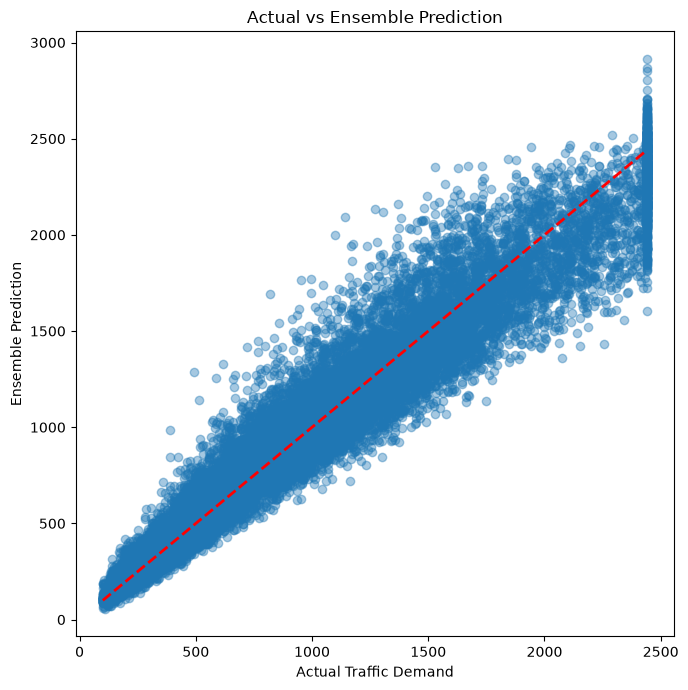

In [29]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    ensemble_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Traffic Demand")

plt.ylabel("Ensemble Prediction")

plt.title("Actual vs Ensemble Prediction")

plt.tight_layout()

plt.savefig(
    "../visualizations/ensemble_actual_vs_predicted.png",
    dpi=300
)

plt.show()

### STACKING (Bonus)

In [30]:
stack_model = StackingRegressor(

    estimators=[

        ("rf", rf),

        ("xgb", xgb)

    ],

    final_estimator=Ridge(),

    cv=5,

    n_jobs=-1

)

In [31]:
stack_model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('xgb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestR...ndom_state=42), XGBRegressor(...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U20](22,)","['hour','day_of_week','geohash_location',...,'rush_hour_indicator', 'signal_density','weather_impact_score']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,Ridge,Ridge()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,22


In [32]:
stack_pred = stack_model.predict(
    X_test
)

stack_results = evaluate_model(
    "Stacking",
    y_test,
    stack_pred
)

print(stack_results)

{'Model': 'Stacking', 'R² Score': 0.9482, 'RMSE': np.float64(143.53), 'MAE': 95.24, 'MAPE': np.float64(13.02)}


In [33]:
comparison = pd.DataFrame([

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    ),

    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    ),

    evaluate_model(
        "LightGBM",
        y_test,
        lgb_pred
    ),

    ensemble_results,

    stack_results

])

display(
    comparison.sort_values(
        "R² Score",
        ascending=False
    )
)

,Model,R² Score,RMSE,MAE,MAPE
3,Weighted Ensemble,0.9486,142.92,94.64,12.91
2,LightGBM,0.9482,143.58,95.04,13.00
1,XGBoost,0.9482,143.60,95.26,13.02
4,Stacking,0.9482,143.53,95.24,13.02
0,Random Forest,0.9207,177.60,115.47,16.06


In [37]:
comparison.to_csv(
    "../data/model_performance.csv",
    index=False
)

In [34]:
joblib.dump(
    stack_model,
    "../models/stacked_model.pkl"
)


['../models/stacked_model.pkl']

In [35]:
import joblib

lgbm = joblib.load("../models/lightgbm.pkl")
xgb = joblib.load("../models/xgboost.pkl")

In [36]:
import sys
sys.path.append("../src")

from ensemble_model import ensemble_predict
ensemble_pred = ensemble_predict(X_test)

print(ensemble_pred[:5])


[ 218.63939702 2205.40031382  783.00168587  150.79489868 1715.11818893]
